In [43]:
import numpy as np
import matplotlib.pyplot as plt

# **Understanding Data Types in Python**

The fundamental difference between Python and languages like C or Java lies in **when** the language verifies the types of your variables and how it allocates memory. This is often summarized as "Dynamic Typing" versus "Static Typing."

---

- **1. Static Typing (C/Java): The "Strict Blueprint"**
    - In languages like C or Java, you must declare the data type of every variable before you use it. The compiler checks these types *before* the program even runs.
        * **Fixed Types:** Once you define `int x = 10;`, that variable `x` can only ever hold an integer. If you try to assign `x = "hello";`, the program will refuse to compile.
        * **Compile-Time Verification:** The compiler acts as a strict guard. It catches type-related errors (like trying to perform math on a string) before the code is executed.
    * **Performance:** Because the compiler knows exactly what type of data each variable holds, it can optimize the machine code effectively. It knows exactly how many bytes of memory an `int` or a `float` needs.


- **2. Dynamic Typing (Python): The "Flexible Label"**
    - In Python, you do not declare types. You simply assign values to names.
        * **Type Labels, Not Boxes:** In Python, a variable is just a "label" (or reference) pointing to an object in memory. You can point the label `x` to an integer, and then immediately point that same label to a string.
        * **Runtime Verification:** Python checks types only when the code actually executes. If you try to perform `5 + "hello"`, Python will throw a `TypeError` **only when the program reaches that specific line**.
        * **Flexibility:** This makes prototyping very fast. You don't have to write boilerplate code for type declarations, which is why Python is favored for data exploration and rapid development.

---

- **Comparison at a Glance**

| Feature | Static (C/Java) | Dynamic (Python) |
| :--- | :--- | :--- |
| **Type Checking** | Compile-time (Before running) | Runtime (During running) |
| **Variable Declaration** | Mandatory | Not required |
| **Flexibility** | Rigid | Highly flexible |
| **Error Catching** | Early (at build time) | Later (at runtime) |
| **Typical Goal** | Performance & Scalability | Speed of Development & Flexibility |

---

- **Why does this matter for your Data Engineering projects?**
    - Since you are working with the **Medallion Architecture**, you are handling various data types (JSONs, Parquet files, CSVs) in your Bronze, Silver, and Gold layers.

* **The Python Trade-off:** In your ETL pipelines, the dynamic nature of Python allows you to write generic functions that can handle different data structures without re-writing code. However, it also means you are more vulnerable to "hidden" runtime errors—like a column that should be an integer suddenly containing strings—that won't be caught until your pipeline crashes during a run.
* **The C/Java Trade-off:** If you were building a massive, mission-critical data processing engine (like Apache Spark, which is written in Scala/Java), static typing is a massive advantage. It ensures that data schemas are locked down and provides the performance required to process petabytes of data efficiently.


> As a Data Engineer, you are essentially using **Python** to orchestrate the high-level flow (flexibility) while relying on underlying **C** or **Java-based** libraries (like Pandas, NumPy, or Spark) to handle the heavy, performance-critical data processing.


## **A Python Integer Is More Than Just an Integer**

To understand how Python and C store an integer, you have to look at the difference between **Value Types** (in C) and **Object Types** (in Python).

- **1. C: The "Fixed Box" (Static)**
    - In C, a `long` variable is a direct map to a specific block of memory. 
        * **Fixed Allocation:** When you declare `long x = 100;`, the C compiler knows exactly how many bytes a `long` requires (typically 8 bytes on a 64-bit system).
        * **Direct Access:** The computer allocates 8 contiguous bytes in memory. The value `100` is written directly into those 8 bytes in binary format.
        * **No Metadata:** The memory contains **only** the value. The program knows it is a `long` because of the variable type defined at compile-time. If you tell the compiler to treat those 8 bytes as a pointer or a double, it will do so blindly—which is why C is fast but dangerous.

---

- **2. Python: The "Object Box" (Dynamic)**
    - In Python, everything is an **object**. Even a simple integer is a complex structure stored on the "heap."
        * **The Variable as a Label:** A Python variable like `x = 100` is not a storage box; it is a **reference** (a pointer) to an object.
        * **The Object Structure:** Because Python must support arbitrary-precision integers (they never overflow, unlike C's `long`), an integer object contains metadata. It is a structure that includes:
            * **Reference count:** Used for memory management (garbage collection).
            * **Type information:** A pointer to the `int` type object (so Python knows it's an integer).
            * **Size information:** How many digits the integer has.
            * **The actual value:** The data itself.
    * **Overhead:** Because of this extra metadata, a simple Python integer consumes significantly more memory (often 28 bytes or more) than the 8 bytes used by a C `long`.

![he difference between C and Python integers](../Images/The_difference_between_C_and_Python_integers.png)

---

- **Comparison Summary**

| Feature | C `long` | Python `int` |
| :--- | :--- | :--- |
| **Size** | Fixed (e.g., 8 bytes) | Dynamic (at least 28 bytes) |
| **Storage** | Raw binary value | Metadata + value |
| **Type Tracking** | None (at runtime) | Stored within the object |
| **Flexibility** | Rigid | Handles arbitrarily large numbers |

---

- **Why this matters for your work**
    - In your **Medallion architecture** project, you are dealing with large datasets:
        1.  **Efficiency:** When you use libraries like **NumPy** or **Pandas**, you are essentially forcing Python to use C-like "fixed boxes" (arrays) under the hood. This is why NumPy is thousands of times faster than standard Python lists—it bypasses the "object" overhead and stores raw integers in contiguous memory just like C.
        2.  **Safety:** Python’s dynamic object structure prevents the integer overflow errors common in C, but the "price" you pay for that safety is higher memory consumption per variable.


## **A Python List Is More Than Just a List**

The difference between a standard Python `list` and a NumPy `array` is one of the most critical concepts for a Data Engineer. It is the difference between a flexible container for "anything" and a high-performance engine for "data."

---

- **1. Python `list`: The Dynamic Container**
    - A Python list is a **dynamic array of references**. It is designed for maximum flexibility, not for performance.

* **Heterogeneous:** A single list can hold an integer, a string, and a dictionary at the same time.
* **Pointer Overhead:** Because the list doesn't know what types it contains, it stores a list of pointers (references) to objects scattered throughout your computer's memory.
* **Memory Inefficiency:** Every item in the list is a full-blown Python object with its own metadata (reference count, type info, etc.).
* **Computational Cost:** To perform an operation (like adding 1 to every element), Python must:
    1.  Follow the pointer to the object.
    2.  Check the type of the object.
    3.  Find the addition method for that type.
    4.  Execute the addition and create a new object.

---

- **2. NumPy `array`: The Fixed-Type Powerhouse**
    - A NumPy array (`ndarray`) is a **block of contiguous memory** designed for fast numerical processing.

* **Homogeneous:** Every element in a NumPy array **must** be the same data type (e.g., `int64`, `float64`).
* **Memory Efficiency:** Because the type is fixed, NumPy doesn't need to store metadata for every single element. It stores the raw data in a solid block of memory.
* **CPU Cache Friendly:** Because the data is contiguous (side-by-side in RAM), your CPU can load chunks of the array into its high-speed cache efficiently. This is the secret behind NumPy's speed.
* **Vectorization:** NumPy operations use "Vectorization." Instead of looping through elements one by one, it performs operations on the entire block of memory at once, often using low-level C and Fortran code that talks directly to your CPU's hardware.

---

![The difference between C and Python lists](../Images/The_difference_between_C_and_Python_lists.png)

- **Comparison Summary**

| Feature | Python `list` | NumPy `array` |
| :--- | :--- | :--- |
| **Data Types** | Heterogeneous (Mixed) | Homogeneous (Same) |
| **Storage** | Pointers to objects (Scattered) | Contiguous memory (Fixed) |
| **Performance** | Slow (due to type checking) | Fast (due to vectorization) |
| **Flexibility** | High (insert/delete anywhere) | Low (fixed size and type) |
| **Memory usage** | High (due to metadata) | Low (raw data only) |

---

- **Why this matters for your `Comptoire-DWH`**
    - In your data warehousing project, your performance depends entirely on how you handle your ETL (Extract, Transform, Load) operations:
        * **Use `lists`** when you are handling small configuration files, metadata dictionaries, or when you need to dynamically grow a structure that contains different types of information.
        * **Use `NumPy arrays` (or Pandas, which is built on them)** when you are processing the **Silver** or **Gold** layer data. If you are applying transformations to millions of rows of sales data, a Python `list` will be the bottleneck that makes your pipeline crawl, whereas a NumPy array will process it almost instantaneously.

## **Fixed-Type Arrays in Python**

Standard Python lists are dynamic and heterogeneous, as we discussed. However, Python provides a built-in module called **`array`** that offers a primitive, fixed-type array implementation. It is often overlooked because NumPy is so powerful, but it is technically a "built-in" way to handle fixed-type data without installing external packages.

---

- **The `array` Module: Python's Built-in Fixed-Type Array**
    - The `array` module stores data in a more compact, C-like format. You must specify a **type code** when you create one, which tells Python exactly how many bytes to allocate for each element.

- **How to use it:**
```python
import array

# 'i' stands for signed integer (usually 4 bytes)
arr = array.array('i', [10, 20, 30, 40])

# This will raise a TypeError because it's fixed-type
# arr.append("not an integer") 
```

---

- **Comparison: Python `list` vs. `array` vs. `NumPy`**

| Feature | Python `list` | Built-in `array` | NumPy `array` |
| :--- | :--- | :--- | :--- |
| **Type** | Dynamic/Mixed | Fixed (defined at creation) | Fixed (defined at creation) |
| **Memory** | High (Pointers) | Low (Raw C-style) | Very Low (Contiguous) |
| **Operations** | Slow (General) | Basic | Fast (Vectorized) |
| **Requirement** | Built-in | Built-in module | Requires installation |

---

- **Why use the `array` module instead of NumPy?**
    - While NumPy is the gold standard for data engineering, the built-in `array` module is useful in specific, niche scenarios:
        1.  **Lightweight requirements:** You are writing a script that cannot have external dependencies (like `numpy`).
        2.  **Memory constraints:** You have a very large sequence of simple integers or floats and need to save memory compared to a standard `list`, but don't need the heavy overhead of the entire NumPy library.
        3.  **Basic storage:** You need to store binary data that maps directly to C data structures for communication with a low-level API.

- **Important Limitation**
    - The built-in `array` module **does not support vectorization.** Even though the data is stored efficiently (like a NumPy array), if you want to add 1 to every element, you still have to use a Python `for` loop, which is slow. NumPy’s true power is its ability to perform math on the *entire block* of memory at the CPU level.

> For your **Medallion architecture** project, you will almost certainly prefer **NumPy** for any data processing because it allows you to perform complex transformations on millions of rows at C-speed, whereas the built-in `array` module would still require slow Python-level iteration.

In [1]:
import array

In [2]:
L = [i for i in range(10)]
arr = array.array('i', L)

arr

array('i', [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [3]:
arr.append(1)

In [4]:
arr

array('i', [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 1])

## **Creating Arrays from Python Lists**

In [2]:
import numpy as np

In [14]:
a = np.array([1, 2, 3, 4, 5])

a

array([1, 2, 3, 4, 5])

In [13]:
# numpy upcats the type in uniform type according to the type promotion rules
b = np.array([1.2, 2, 3, 4, 5.17])

b

array([1.2 , 2.  , 3.  , 4.  , 5.17])

In [16]:
# define explicitly the data type of values
a = np.array([1, 2, 3, 4, 5], dtype=np.float32)

a

array([1., 2., 3., 4., 5.], dtype=float32)

In [17]:
# Nested lists result in multidimensional arrays
b = np.array([range(i, i+3) for i in [2, 4, 6]])

b

array([[2, 3, 4],
       [4, 5, 6],
       [6, 7, 8]])

> The inner lists are treated as **rows** of the resulting two-dimensional array.

## **Creating Arrays from Scratch**

In [18]:
# Create a length-10 integer array filled with 0s

np.zeros(10, dtype=np.int8)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int8)

In [19]:
# Create a 3x5 floating-point array filled with 1s

np.ones((3, 5), dtype=np.int8)

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=int8)

In [20]:
# Create a 3x5 array filled with 3.14

np.full((3, 5), fill_value=3.14, dtype=np.float16)

array([[3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14],
       [3.14, 3.14, 3.14, 3.14, 3.14]], dtype=float16)

In [23]:
# Create an array filled with a linear sequence
# starting at 0, ending at 20, stepping by 2
# (this is similar to the built-in range function)

np.arange(0, 20, 2)

array([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])

In [26]:
# Create an array of five values evenly spaced between 0 and 1

np.linspace(0, 1, 5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [28]:
# Create a 3x3 array of uniformly distributed
# pseudorandom values between 0 and 1

np.random.random(size=(3, 3))

array([[0.24588923, 0.78500281, 0.02922493],
       [0.30647426, 0.03940002, 0.29479793],
       [0.90483863, 0.03809542, 0.80269574]])

In [29]:
# Create a 3x3 array of normally distributed pseudorandom
# values with mean 0 and standard deviation 1

np.random.normal(0, 1, size=(3, 3))

array([[ 1.30286221,  0.13618128,  1.18219448],
       [ 0.20777218,  0.35041344,  0.33138945],
       [ 0.29348422, -0.24460001, -0.48031944]])

In [30]:
# Create a 3x3 array of pseudorandom integers in the interval [0, 10)

np.random.randint(0, 10, size=(3, 3))

array([[5, 0, 6],
       [0, 1, 8],
       [9, 4, 8]])

In [31]:
# Create a 3x3 identity matrix

np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [32]:
# Create an uninitialized array of three integers; the values will be
# whatever happens to already exist at that memory location

np.empty(3)

array([1., 1., 1.])

## **NumPy Standard Data Types**

| Data type | Description |
| :--- | :--- |
| **bool_** | Boolean (True or False) stored as a byte |
| **int_** | Default integer type (same as C long; normally either int64 or int32) |
| **intc** | Identical to C int (normally int32 or int64) |
| **intp** | Integer used for indexing (same as C ssize_t; normally either int32 or int64) |
| **int8** | Byte (–128 to 127) |
| **int16** | Integer (–32768 to 32767) |
| **int32** | Integer (–2147483648 to 2147483647) |
| **int64** | Integer (–9223372036854775808 to 9223372036854775807) |
| **uint8** | Unsigned integer (0 to 255) |
| **uint16** | Unsigned integer (0 to 65535) |
| **uint32** | Unsigned integer (0 to 4294967295) |
| **uint64** | Unsigned integer (0 to 18446744073709551615) |
| **float_** | Shorthand for float64 |
| **float16** | Half-precision float: sign bit, 5 bits exponent, 10 bits mantissa |
| **float32** | Single-precision float: sign bit, 8 bits exponent, 23 bits mantissa |
| **float64** | Double-precision float: sign bit, 11 bits exponent, 52 bits mantissa |
| **complex_** | Shorthand for complex128 |
| **complex64** | Complex number, represented by two 32-bit floats |
| **complex128** | Complex number, represented by two 64-bit floats |

# **The Basics of NumPy Arrays**

## **NumPy Array Attributes**

In [1]:
import numpy as np

In [107]:
rng = np.random.default_rng(seed=1071) # # seed for reproducibility

x1 = rng.integers(10, size=10)        # one-dimensional array
x2 = rng.integers(10, size=(3, 4))    # two-dimensional array
x3 = rng.integers(10, size=(3, 4, 5)) # three-dimensional array

In [108]:
print("the number of dimension : ", x3.ndim)
print("the shape of array : ", x3.shape)
print("The total of element in array : ", x3.size)
print("the data type of elements in array : ", x3.dtype)

the number of dimension :  3
the shape of array :  (3, 4, 5)
The total of element in array :  60
the data type of elements in array :  int64


## **Array Indexing: Accessing Single Elements**

In [109]:
x1

array([7, 2, 1, 8, 3, 2, 9, 9, 0, 3])

In [110]:
x1[::2]

array([7, 1, 3, 9, 0])

In [111]:
x1[1::2]

array([2, 8, 2, 9, 3])

In [112]:
x1[-10:-1]

array([7, 2, 1, 8, 3, 2, 9, 9, 0])

In [113]:
x1[::-1]

array([3, 0, 9, 9, 2, 3, 8, 1, 2, 7])

In [114]:
x1[-10:-1:-1]

array([], dtype=int64)

- **Start:** Index -10.
- **Stop:** Index -1 (exclusive).
- **Step:** -1.
- **Direction:** When the step is negative, the slice must move from right to left (decreasing indices).
- **The Conflict:** You are starting at index -10 and trying to move to the right (towards index -1) by stepping negatively (-1). This is logically impossible because your start point is to the left of your stop point, but your direction is pointing to the left.

- The Rule of Slicing
    - In Python slicing:
        - If **step > 0**, the start must be less than the stop.
        - If **step < 0**, the start must be greater than the stop.

In [115]:
x1[-1:-100:-1] # we can set the ens of slacing to the out of range bu this don't cause error

array([3, 0, 9, 9, 2, 3, 8, 1, 2, 7])

In [116]:
x1[0:100] # also in positive case

array([7, 2, 1, 8, 3, 2, 9, 9, 0, 3])

In [117]:
x2

array([[8, 8, 6, 1],
       [2, 3, 5, 8],
       [6, 4, 6, 5]])

In [118]:
x2[0, 0] # slicing by (rows, columns)

np.int64(8)

In [119]:
x2[0, -1]

np.int64(1)

In [120]:
x2[:, 1:3]

array([[8, 6],
       [3, 5],
       [4, 6]])

In [121]:
x2[1, 1:3] = 8, 8

x2

array([[8, 8, 6, 1],
       [2, 8, 8, 8],
       [6, 4, 6, 5]])

In [122]:
x2[0, 0] = 3.3145 # # this will be truncated to ensure the Heterogeneity

x2

array([[3, 8, 6, 1],
       [2, 8, 8, 8],
       [6, 4, 6, 5]])

## **Array Slicing: Accessing Subarrays**

### **One-Dimensional Subarrays**

In [123]:
x1

array([7, 2, 1, 8, 3, 2, 9, 9, 0, 3])

In [124]:
x1[::2]

array([7, 1, 3, 9, 0])

In [125]:
x1[1::2]

array([2, 8, 2, 9, 3])

In [126]:
x1[-1:-6:-1]

array([3, 0, 9, 9, 2])

In [127]:
x1[4::-1]

array([3, 8, 1, 2, 7])

### **Multidimensional Subarrays**

In [128]:
x2

array([[3, 8, 6, 1],
       [2, 8, 8, 8],
       [6, 4, 6, 5]])

In [129]:
x2[:, ::2]

array([[3, 6],
       [2, 8],
       [6, 6]])

In [130]:
x2[::-1, ::-1]

array([[5, 6, 4, 6],
       [8, 8, 8, 2],
       [1, 6, 8, 3]])

In [131]:
x2[:, 0]

array([3, 2, 6])

In [132]:
x2[0]

array([3, 8, 6, 1])

In [133]:
x2[:, 1]

array([8, 8, 4])

In [134]:
x2[::-1, 1]

array([4, 8, 8])

### **Subarrays as No-Copy Views**

> Unlike Python list slices, NumPy array slices are returned as **views** rather than copies of the array data.

In [135]:
x2

array([[3, 8, 6, 1],
       [2, 8, 8, 8],
       [6, 4, 6, 5]])

In [136]:
x2_sub = x2[:2, 1:3]

x2_sub

array([[8, 6],
       [8, 8]])

In [137]:
x2_sub[0, 0] = 88

x2

array([[ 3, 88,  6,  1],
       [ 2,  8,  8,  8],
       [ 6,  4,  6,  5]])

In [138]:
x2_sub[1, :] = 88

x2

array([[ 3, 88,  6,  1],
       [ 2, 88, 88,  8],
       [ 6,  4,  6,  5]])

In [139]:
x2_sub[1, :] = [88, 99]

x2

array([[ 3, 88,  6,  1],
       [ 2, 88, 99,  8],
       [ 6,  4,  6,  5]])

In [140]:
x2_sub

array([[88,  6],
       [88, 99]])

> but it can be advantageous: for example, when working with large datasets, we can access and process pieces of these datasets without the need to copy the underlying data buffer.

### **Creating Copies of Arrays**

In [141]:
x2

array([[ 3, 88,  6,  1],
       [ 2, 88, 99,  8],
       [ 6,  4,  6,  5]])

In [142]:
x2_sub_copy = x2[:2, 1:3].copy()

x2_sub_copy

array([[88,  6],
       [88, 99]])

> If we now modify this subarray, the original array is not touched

In [143]:
x2_sub_copy[1, :] = [8, 9]

x2

array([[ 3, 88,  6,  1],
       [ 2, 88, 99,  8],
       [ 6,  4,  6,  5]])

In [144]:
x2_sub_copy

array([[88,  6],
       [ 8,  9]])

## **Reshaping of Arrays**

In [157]:
grid = np.arange(1, 10).reshape((3, 3))

grid

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [158]:
grid.reshape((1, -1))

grid

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [159]:
grid.reshape((-1))

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [160]:
grid.reshape((1, -1))

array([[1, 2, 3, 4, 5, 6, 7, 8, 9]])

In [161]:
x = np.array([1, 2, 3])

x

array([1, 2, 3])

In [162]:
x.reshape((1, 3))

array([[1, 2, 3]])

In [163]:
x.reshape((3, 1))

array([[1],
       [2],
       [3]])

In [164]:
x[np.newaxis, :] # row vector via newaxis

array([[1, 2, 3]])

In [165]:
x[:, np.newaxis] # column vector via newaxis

array([[1],
       [2],
       [3]])

## **Array Concatenation and Splitting**

### **Concatenation of Arrays**

In [166]:
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])

np.concatenate([x, y])

array([1, 2, 3, 4, 5, 6])

In [168]:
z = np.array([7, 8, 9])

np.concatenate([x, y, z])

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [169]:
grid

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [171]:
grid2 = np.arange(1, 10).reshape((3, 3))

grid2

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [173]:
np.concatenate([grid, grid2]) # concatenate along the first axis (rows)

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9],
       [1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [175]:
np.concatenate([grid, grid2], axis=1) # concatenate along the second axis (columns)

array([[1, 2, 3, 1, 2, 3],
       [4, 5, 6, 4, 5, 6],
       [7, 8, 9, 7, 8, 9]])

> For working with arrays of mixed dimensions, it can be clearer to use the **np.vstack** **(vertical stack)** and **np.hstack (horizontal stack)** functions 

In [179]:
x

array([1, 2, 3])

In [177]:
x.ndim, grid.ndim

(1, 2)

In [178]:
np.vstack([x, grid])

array([[1, 2, 3],
       [1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [181]:
y = np.arange(1, 4).reshape((3, 1))

y

array([[1],
       [2],
       [3]])

In [182]:
np.hstack([y, grid])

array([[1, 1, 2, 3],
       [2, 4, 5, 6],
       [3, 7, 8, 9]])

In [202]:
z = np.arange(1, 13).reshape((3, 4))

z

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [204]:
np.dstack((z, x3))

array([[[ 1,  1,  8,  7,  0,  6],
        [ 2,  2,  9,  5,  5,  6],
        [ 3,  0,  6,  0,  4,  6],
        [ 4,  3,  5,  7,  9,  2]],

       [[ 5,  9,  3,  3,  6,  9],
        [ 6,  3,  4,  8,  5,  5],
        [ 7,  3,  3,  0,  0,  4],
        [ 8,  8,  7,  5,  2,  9]],

       [[ 9,  1,  8,  0,  5,  1],
        [10,  2,  2,  6,  8,  4],
        [11,  9,  4,  1,  5,  3],
        [12,  7,  8,  3,  8,  0]]])

In [205]:
x3.shape, z.shape

((3, 4, 5), (3, 4))

> Similarly, for higher-dimensional arrays, **np.dstack** will stack arrays along the third axis.

### **Splitting of Arrays**

In [208]:
x = [1, 2, 3, 99, 99, 3, 2, 1]
x1, x2, x3 = np.split(x, [3, 5])

print(x1, x2, x3)

[1 2 3] [99 99] [3 2 1]


In [212]:
x1, x2, x3 = np.split(x, [2, 6])

print(x1, x2, x3)

[1 2] [ 3 99 99  3] [2 1]


In [213]:
grid = np.arange(16).reshape((4, 4))

grid

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

In [214]:
np.vsplit(grid, 2)

[array([[0, 1, 2, 3],
        [4, 5, 6, 7]]),
 array([[ 8,  9, 10, 11],
        [12, 13, 14, 15]])]

In [216]:
np.vsplit(grid, [3, 6])

[array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15]]),
 array([], shape=(0, 4), dtype=int64)]

In [217]:
np.hsplit(grid, 2)

[array([[ 0,  1],
        [ 4,  5],
        [ 8,  9],
        [12, 13]]),
 array([[ 2,  3],
        [ 6,  7],
        [10, 11],
        [14, 15]])]

In [218]:
np.split(grid, [3, 6])

[array([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]]),
 array([[12, 13, 14, 15]]),
 array([], shape=(0, 4), dtype=int64)]

In [229]:
x3 = np.arange(60).reshape((3, 4, 5))

x3.shape

(3, 4, 5)

In [234]:
x3

array([[[ 0,  1,  2,  3,  4],
        [ 5,  6,  7,  8,  9],
        [10, 11, 12, 13, 14],
        [15, 16, 17, 18, 19]],

       [[20, 21, 22, 23, 24],
        [25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34],
        [35, 36, 37, 38, 39]],

       [[40, 41, 42, 43, 44],
        [45, 46, 47, 48, 49],
        [50, 51, 52, 53, 54],
        [55, 56, 57, 58, 59]]])

In [237]:
np.dsplit(x3, [4, 6])

[array([[[ 0,  1,  2,  3],
         [ 5,  6,  7,  8],
         [10, 11, 12, 13],
         [15, 16, 17, 18]],
 
        [[20, 21, 22, 23],
         [25, 26, 27, 28],
         [30, 31, 32, 33],
         [35, 36, 37, 38]],
 
        [[40, 41, 42, 43],
         [45, 46, 47, 48],
         [50, 51, 52, 53],
         [55, 56, 57, 58]]]),
 array([[[ 4],
         [ 9],
         [14],
         [19]],
 
        [[24],
         [29],
         [34],
         [39]],
 
        [[44],
         [49],
         [54],
         [59]]]),
 array([], shape=(3, 4, 0), dtype=int64)]

# **Computation on NumPy Arrays**

The speed of NumPy is not a "magic trick"—it is a direct result of how it handles memory and CPU instructions. When you perform **vectorized operations** in NumPy, you are shifting the workload from Python's slow, high-level interpreter to highly optimized, low-level C and Fortran code.

Here is how vectorization makes NumPy so fast:

---

- **1. The "Loop" Problem in Standard Python**
    - In a standard Python list, if you want to add 1 to every element, you must write a `for` loop.

* **Interpreter Overhead:** For every single iteration, Python has to:
    1.  Check the type of the current object.
    2.  Find the addition method for that type.
    3.  Execute the addition.
    4.  Create a new object for the result.
* **The Result:** The computer spends more time "managing" the loop and the objects than actually doing the math.

---

- **2. The Vectorization Solution (The C-Way)**
    - When you use a vectorized NumPy operation like `array + 1`, you trigger a mechanism called **Unbuffered (or Compiled) Loops**.

* **Statically Typed Operations:** Because NumPy arrays are fixed-type (e.g., every element is a `float64`), NumPy knows *exactly* what type of data it is dealing with. It doesn't need to check types inside the loop.
* **Pre-compiled C Loops:** Instead of running the loop in Python, NumPy calls a pre-compiled function written in C. This C loop runs at the full speed of your CPU, without the "interference" of the Python interpreter.
* **Contiguous Memory Access:** NumPy stores data in **contiguous blocks** of memory. Your CPU is designed to load these blocks into its high-speed **cache** (L1/L2) efficiently. When the data is right next to each other, the CPU can read the next value before it even finishes processing the current one (a technique called *pipelining*).

---

- **3. SIMD (Single Instruction, Multiple Data)**
    - This is the "secret sauce" of modern CPU optimization that NumPy leverages. 

- Modern CPUs have **SIMD instructions** (like SSE or AVX). Instead of adding two numbers at a time, these instructions allow the CPU to perform the *same mathematical operation* on multiple data points **simultaneously** in a single clock cycle.
    * **Standard Python:** Adds `1 + 1`, then `2 + 1`, then `3 + 1`...
    * **NumPy (Vectorized):** Tells the CPU, "Take these 8 numbers in memory and add 1 to all of them at once."

---

- **Summary of the Speed Gains**

| Feature | Standard Python `list` | NumPy `ndarray` |
| :--- | :--- | :--- |
| **Looping** | Python level (Slow) | C level (Fast) |
| **Type Checking** | Every iteration | Once (at start) |
| **Memory** | Scattered pointers | Contiguous blocks |
| **CPU Usage** | Scalar (one by one) | SIMD (parallel batches) |

- **Why this is critical for your `Comptoire-DWH`**
    - Since you are building a Medallion architecture project, you will be performing bulk transformations—like calculating profit margins on thousands of transactions or normalizing sensor data in your Silver layer.
        * **If you use a loop:** You are forcing Python to iterate, which will make your pipeline feel "heavy" as your data grows to millions of rows.
        * **If you use vectorization:** You are letting the CPU perform the work at hardware speeds. 

> By thinking in terms of **whole-array operations** rather than "for-each-item" logic, you are effectively programming your ETL pipeline to scale automatically.


## **The Slowness of Loops**

To make Python faster, you have to bypass the **CPython** bottleneck: the overhead of the interpreter, dynamic type checking, and the overhead of Python's object model. **PyPy, Cython, and Numba** use three completely different strategies to solve this.

---

- **1. PyPy: The "Just-In-Time" (JIT) Compiler**
    - PyPy is an alternative implementation of Python. It replaces the standard CPython interpreter with a JIT compiler.

* **How it works:** As your code runs, PyPy identifies "hot paths" (code that runs repeatedly, like loops). It compiles these paths into machine code on the fly. It also uses **Tracing JIT**, which monitors how your code behaves and optimizes it based on the actual data types it sees.
* **Why it's fast:** It eliminates the interpreter overhead for repeated tasks.
* **Weaknesses:**
    * **Memory usage:** It consumes significantly more RAM than CPython.
    * **C-Extension Compatibility:** It doesn't support CPython C-extensions (like older versions of NumPy) perfectly, though it has made huge progress.

---

- **2. Cython: The "Static Compiler"**
    - Cython is a language that is a superset of Python. It allows you to add static C types to your Python code and compiles it into C.

* **How it works:** You write Python code, add C type declarations (e.g., `cdef int i`), and Cython translates that into a C file, which is then compiled into a Python extension module.
* **Why it's fast:** It turns Python into essentially C code. It bypasses the Python object overhead entirely for the typed sections.
* **Weaknesses:**
    * **Complexity:** You have to manually rewrite parts of your Python code to use C-types.
    * **Compilation step:** You must manage a build/compilation process, which complicates deployment.

---

- **3. Numba: The "Dynamic JIT Decorator"**
    - Numba is a library that allows you to accelerate Python functions using the **LLVM compiler infrastructure**.

* **How it works:** You simply add a decorator (e.g., `@jit`) to your function. Numba analyzes your function, figures out the data types, and compiles it to machine code the first time you call it.
* **Why it's fast:** It offers near-C performance for numerical loops without requiring you to change your code or set up a complex C-compiler toolchain.
* **Weaknesses:**
    * **"Numba-fication" overhead:** The first time you call a function, there is a delay while it compiles.
    * **Limited support:** It works best with pure Python/NumPy code. If your code uses complex Python classes or dictionaries, Numba often falls back to "object mode," which is much slower.

---

- **Comparison Summary**

| Feature | PyPy | Cython | Numba |
| :--- | :--- | :--- | :--- |
| **Philosophy** | Drop-in replacement | Add types, compile to C | Decorator-based JIT |
| **Ease of Use** | Very High | Low (requires refactoring) | High |
| **Best For** | Pure Python loops | Wrapping C libraries/Apps | Scientific/Numerical code |
| **Compilation** | JIT (at runtime) | Ahead-of-time (AOT) | JIT (at runtime) |

---

- **Which one should you use for your `Comptoire-DWH`?**
    - As a **Data Engineer** dealing with Medallion architecture:
        1.  **Use Numba:** If you are doing intense numerical cleaning (e.g., math on columns, custom aggregation algorithms). It’s the easiest to drop into existing data pipelines without rewriting your project.
        2.  **Use Cython:** Only if you are building a custom, high-performance library that needs to be packaged and reused across different environments, or if you need to integrate directly with C/C++ memory structures.
        3.  **Avoid PyPy:** If you rely heavily on the standard scientific stack (Pandas, SciPy, etc.), PyPy can sometimes be more of a headache to configure than it is worth compared to just using Numba.

In [240]:
rng = np.random.default_rng(seed=1071)

def compute_reciprocals(arr):
    res = np.empty(len(arr))

    for i in range(len(arr)):
        res[i] = 1.0 / arr[i]

    return res

In [243]:
values = rng.integers(1, 10, size=5)

values

array([7, 3, 2, 8, 4])

In [244]:
compute_reciprocals(values)

array([0.14285714, 0.33333333, 0.5       , 0.125     , 0.25      ])

In [247]:
massive_data = rng.integers(1, 100, size=1000000)

%timeit compute_reciprocals(massive_data)

1.58 s ± 20 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


**CPython** is the reference implementation of the Python programming language. When you download and install Python from `python.org`, you are downloading CPython.

It is called "CPython" because it is written primarily in **C** (with some Python code for the standard library), and it is designed to run on top of the C language runtime.

---

- **How CPython Works: The Pipeline**
    - CPython doesn't execute your source code directly; it performs a two-step process to bridge the gap between human-readable Python and your computer's CPU.

1.  **Compiler (Source to Bytecode):** When you run a script, CPython first compiles your `.py` files into **bytecode** (a low-level, platform-independent set of instructions). This is stored as `.pyc` files in your `__pycache__` directory.
2.  **Virtual Machine (Bytecode to Machine Code):** The **Python Virtual Machine (PVM)** then interprets that bytecode. It iterates through the bytecode instructions and executes them one by one, calling the underlying C functions to perform the actual logic (e.g., allocating memory, performing math, or writing to a file).

---

- **The Defining Characteristics**

* **The GIL (Global Interpreter Lock):** This is CPython's most famous constraint. The GIL is a mutex (lock) that prevents multiple native threads from executing Python bytecodes at once. This means that even if you have a multi-core processor, your Python code will only execute on one core at a time for CPU-bound tasks. This is why Data Engineers often use **multiprocessing** (running separate processes) instead of **multithreading** for heavy ETL tasks.
* **Reference Counting:** CPython manages memory primarily through reference counting. Every object has a counter tracking how many parts of your code are "using" it. When the count hits zero, CPython immediately frees the memory. It also includes a **Garbage Collector (GC)** to handle "circular references" that the counter can't catch.
* **Extensibility:** CPython is designed to be easily extended with C and C++. This is exactly why libraries like **NumPy, Pandas, and TensorFlow** are so fast—they are written in C/C++ and provided as extensions to the CPython interpreter, allowing them to bypass the PVM's overhead for high-performance calculations.

---

- **Why this matters for your projects**
    - Understanding CPython helps explain the limitations and strengths you encounter in your Data Engineering workflows:
        * **Performance Limits:** If your ETL scripts are slow, it is often because you are hitting the "interpreter wall." Every bytecode instruction takes time to dispatch. Moving logic into libraries like **Pandas** or **Polars** (which are C/Rust extensions) is your best way to escape this.
        * **Memory usage:** Because CPython uses an object-based system, it uses significantly more RAM than a C-based system would for the same data. This is why you must be mindful of memory usage in your Medallion architecture, especially when handling large batches in the Silver layer.
        * **Portability:** Because CPython compiles to bytecode and runs on the PVM, your code works exactly the same on your **Kali Linux** machine as it would on a Windows or macOS server.


## **Introducing Ufuncs**

In [248]:
print(compute_reciprocals(values))
print(1.0 / values)

[0.14285714 0.33333333 0.5        0.125      0.25      ]
[0.14285714 0.33333333 0.5        0.125      0.25      ]


In [249]:
%timeit 1.0 / massive_data

1.64 ms ± 99.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [251]:
np.arange(6) / np.arange(1, 7)

array([0.        , 0.5       , 0.66666667, 0.75      , 0.8       ,
       0.83333333])

In NumPy, a **Universal Function (often called a `ufunc`)** is a function that performs element-wise operations on data in `ndarray` objects. 

These are the backbone of NumPy's speed. While standard Python functions work on scalar objects, `ufuncs` are designed to execute vector operations efficiently at the C level.

---

- **1. Why `ufuncs` are special**
    - A `ufunc` is essentially a "wrapper" around highly optimized C code. When you call one, NumPy iterates over the array in C, avoiding the slow loop overhead of the Python interpreter.

* **Vectorization:** They apply operations to the whole array without an explicit loop.
* **Broadcasting:** They can automatically handle operations between arrays of different shapes (e.g., adding a scalar to an array, or adding a 1D row to a 2D matrix).
* **Type Flexibility:** They handle different data types and handle casting automatically.

---

- **2. Types of `ufuncs`**

- **A. Unary `ufuncs` (One input array)**
    - These compute values for each element in a single array.
* **Examples:** `np.sqrt()`, `np.exp()`, `np.sin()`, `np.log()`, `np.abs()`.
* **Example Code:**
    ```python
    import numpy as np
    arr = np.array([1, 4, 9, 16])
    result = np.sqrt(arr) # Returns [1., 2., 3., 4.]
    ```

- **B. Binary `ufuncs` (Two input arrays)**
    - These take two arrays (or one array and a scalar) and perform an operation element-by-element.
* **Examples:** `np.add()`, `np.subtract()`, `np.multiply()`, `np.divide()`, `np.power()`.
* **Example Code:**
    ```python
    arr1 = np.array([1, 2, 3])
    arr2 = np.array([10, 20, 30])
    result = np.add(arr1, arr2) # Returns [11, 22, 33]
    ```

---

- **3. Key `ufunc` Features for Data Engineering**
    - When working on your Data Warehouse project, you can use these methods to perform heavy data transformations instantly:

| Method | Description |
| :--- | :--- |
| **`reduce`** | Repeatedly applies a binary operator until a single value is returned (e.g., `np.add.reduce(arr)` sums the whole array). |
| **`accumulate`** | Returns an array of the intermediate results (e.g., `np.add.accumulate(arr)` gives a running total). |
| **`outer`** | Performs the operation on every pair of elements from two arrays (creates a 2D matrix of results). |



- **Why this matters for your `Comptoire-DWH`**
    - Since you are implementing a **Medallion Architecture**, you will often need to apply complex transformations to massive columns of data (e.g., normalizing price data in Silver or calculating cumulative aggregates for Gold).

Using `ufuncs` instead of list comprehensions is the single biggest performance gain you can achieve in Python. **Never write a `for` loop to perform math on a NumPy array if a `ufunc` exists for that operation.**

## **Exploring NumPy’s Ufuncs**

### **Array Arithmetic**

In [252]:
x = np.arange(4)

x

array([0, 1, 2, 3])

In [261]:
print("adding : ", np.add(x, 5))
print("subtracting : ", np.subtract(x, 5))
print("dividing : ", np.divide(x, 5))
print("integer division : ", np.floor_divide(x, 5))
print("remainder of division : ", np.divmod(x, 5))
print("multipliying : ", np.multiply(x, 5))
print("square : ", np.power(x, 2))

adding :  [5 6 7 8]
subtracting :  [-5 -4 -3 -2]
dividing :  [0.  0.2 0.4 0.6]
integer division :  [0 0 0 0]
remainder of division :  (array([0, 0, 0, 0]), array([0, 1, 2, 3]))
multipliying :  [ 0  5 10 15]
square :  [0 1 4 9]


| Operator | Equivalent ufunc | Description |
| :--- | :--- | :--- |
| `+` | `np.add` | Addition (e.g., 1 + 1 = 2) |
| `-` | `np.subtract` | Subtraction (e.g., 3 - 2 = 1) |
| `-` | `np.negative` | Unary negation (e.g., -2) |
| `*` | `np.multiply` | Multiplication (e.g., 2 * 3 = 6) |
| `/` | `np.divide` | Division (e.g., 3 / 2 = 1.5) |
| `//` | `np.floor_divide` | Floor division (e.g., 3 // 2 = 1) |
| `**` | `np.power` | Exponentiation (e.g., 2 ** 3 = 8) |
| `%` | `np.mod` | Modulus/remainder (e.g., 9 % 4 = 1) |

### **Absolute Value**

In [268]:
x = np.negative(x)

x

array([ 0, -1, -2, -3])

In [269]:
np.absolute(x)

array([0, 1, 2, 3])

In [270]:
np.abs(x)

array([0, 1, 2, 3])

In [271]:
np.abs(np.array([3 - 4j, 4 - 3j, 2 + 0j, 0 + 1j])) # handle complex data, in which case it returns the magnitude

array([5., 5., 2., 1.])

### **Trigonometric Functions**

In [272]:
theta = np.linspace(0, np.pi, 3)

theta

array([0.        , 1.57079633, 3.14159265])

In [273]:
print("sin(theta) : ", np.sin(theta))
print("cos(theta) : ", np.cos(theta))
print("tan(theta) : ", np.tan(theta))

sin(theta) :  [0.0000000e+00 1.0000000e+00 1.2246468e-16]
cos(theta) :  [ 1.000000e+00  6.123234e-17 -1.000000e+00]
tan(theta) :  [ 0.00000000e+00  1.63312394e+16 -1.22464680e-16]


In [275]:
x = np.array([-1, 0, 1])

print("arcsin(x) = ", np.arcsin(x))
print("arccos(x) = ", np.arccos(x))
print("arctan(x) = ", np.arctan(x))

arcsin(x) =  [-1.57079633  0.          1.57079633]
arccos(x) =  [3.14159265 1.57079633 0.        ]
arctan(x) =  [-0.78539816  0.          0.78539816]


### **Exponents and Logarithms**

In [276]:
x = np.array([1, 2, 3, 4])

x

array([1, 2, 3, 4])

In [279]:
print("exp(x) : ", np.exp(x))
print("2^x : ", np.exp2(x))
print("n^x : ", np.power(3, x))

exp(x) :  [ 2.71828183  7.3890561  20.08553692 54.59815003]
2^x :  [ 2.  4.  8. 16.]
n^x :  [ 3  9 27 81]


In [280]:
print("ln(x) : ", np.log(x))
print("log2(x) : ", np.log2(x))
print("log10(x) : ", np.log10(x))

ln(x) :  [0.         0.69314718 1.09861229 1.38629436]
log2(x) :  [0.        1.        1.5849625 2.       ]
log10(x) :  [0.         0.30103    0.47712125 0.60205999]


- There are also some **specialized versions** that are useful for maintaining precision with very small input:

In [281]:
x = np.array([0, 0.001, 0.01, 0.1])

x

array([0.   , 0.001, 0.01 , 0.1  ])

In [282]:
print("exp(x) - 1 : ", np.expm1(x))
print("log(x + 1) : ", np.log1p(x))

exp(x) - 1 :  [0.         0.0010005  0.01005017 0.10517092]
ln(x) + 1 :  [0.         0.0009995  0.00995033 0.09531018]


In [284]:
print(np.exp(x) - 1)
print(np.log(x + 1))

[0.         0.0010005  0.01005017 0.10517092]
[0.         0.0009995  0.00995033 0.09531018]


> When x is very small, these functions give more precise values than if the raw **np.log** or **np.exp** were to be used.

### **Specialized Ufuncs**

In [285]:
from scipy import special

In [286]:
x = np.array([1, 5, 10])

x

array([ 1,  5, 10])

In [289]:
# 'special.gamma(x)' computes the Gamma function, which is the extension of 
# the factorial function (n!) to complex and real numbers. 
# For a positive integer n, gamma(n) = (n-1)!
print("gamma(x) : ", special.gamma(x))

# 'special.gammaln(x)' computes the natural logarithm of the absolute value 
# of the Gamma function. This is preferred in data science and statistics 
# because Gamma values grow extremely fast; working with the log-space 
# prevents numerical overflow errors in your calculations.
print("ln|gamma(x)| : ", special.gammaln(x))

# 'special.beta(a, b)' computes the Beta function, often used in Bayesian 
# statistics and probability theory. It is related to the Gamma function 
# by the identity: Beta(a, b) = (gamma(a) * gamma(b)) / gamma(a + b).
print("beta(x) : ", special.beta(x, 2))

gamma(x) :  [1.0000e+00 2.4000e+01 3.6288e+05]
ln|gamma(x)| :  [ 0.          3.17805383 12.80182748]
beta(x) :  [0.5        0.03333333 0.00909091]


In [291]:
x = np.array([0, 0.3, 0.7, 1.0])

x

array([0. , 0.3, 0.7, 1. ])

In [292]:
# 'special.erf(x)' is the Error Function. It represents the probability 
# that a random variable from a normal distribution falls within a 
# specific range. It is the integral of the Gaussian curve.
print("erf(x) : ", special.erf(x))

# 'special.erfc(x)' is the Complementary Error Function, defined as 1 - erf(x).
# It is used when you are interested in the "tail" of a distribution 
# (the probability of values greater than x) rather than the center.
print("erfc(x) : ", special.erfc(x))

# 'special.erfinv(x)' is the Inverse Error Function. It is used to find the 
# value 'x' that corresponds to a specific probability. This is crucial 
# for calculating confidence intervals or performing quantile transformations.
print("erfinv(x) : ", special.erfinv(x))

erf(x) :  [0.         0.32862676 0.67780119 0.84270079]
erfc(x) :  [1.         0.67137324 0.32219881 0.15729921]
erfinv(x) :  [0.         0.27246271 0.73286908        inf]


## **Advanced Ufunc Features**

### **Specifying Output**

In [298]:
x = np.arange(5)
y = np.arange(5)
z = np.empty((len(x)))

np.add(x, y, out=z)

z

array([0., 2., 4., 6., 8.])

In [308]:
y = np.zeros(10)
x = np.arange(5)

In [309]:
np.power(2, x, out=y[::2])

array([ 1.,  2.,  4.,  8., 16.])

In [310]:
y

array([ 1.,  0.,  2.,  0.,  4.,  0.,  8.,  0., 16.,  0.])

- The fundamental difference between **`a + b`** and **`np.add(a, b, out=y)`** lies in memory management and the lifecycle of data: the standard operator `+` is designed for readability and convenience by automatically allocating a **new** memory buffer for every result, which simplifies your code but introduces overhead through frequent memory allocation and garbage collection during large-scale operations. In contrast, the `out=y` parameter is an optimization tool that forces NumPy to perform the operation **in-place** by overwriting an existing, pre-allocated memory block, thereby eliminating the cost of new allocations and providing the maximum possible  efficiency required for high-performance ETL pipelines in your Medallion architecture.

### **Aggregations**

The **`np.reduce`** method, accessed through ufuncs like **`np.add.reduce`** or **`np.multiply.reduce`**, collapses an entire array into a single summary value by repeatedly applying a specific binary operation across all elements along a chosen axis. Instead of writing a manual loop to iterate through every item, **`reduce`** instructs NumPy to process the array sequentially—or in parallel at the C level—by combining the first two elements, then applying the result to the next element, and so on, until only one result remains. This is highly efficient for calculating cumulative metrics in your Data Warehouse, such as finding the total sum of all transactions in a column or the product of a series of factors, as it leverages optimized, low-level execution that bypasses the performance bottlenecks of Python's standard looping structures.

In [314]:
x = np.arange(1, 10)

x

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [315]:
np.add.reduce(x)

np.int64(45)

In [316]:
np.multiply.reduce(x)

np.int64(362880)

The **`np.accumulate`** method, available via ufuncs like **`np.add.accumulate`** or **`np.multiply.accumulate`**, generates a running sequence of intermediate results by applying a binary operation element-by-element across an array and returning an output of the same shape as the input. Unlike **`reduce`**, which collapses an entire array into a single final value, **`accumulate`** preserves every step of the computation, effectively creating a "prefix sum" or "prefix product" where each position `i` in the resulting array contains the aggregate of all elements from the start up to that index. This makes it an essential tool for data engineering tasks such as calculating running totals, tracking progressive growth metrics, or generating time-series cumulative statistics, as it performs these operations in a single pass at the optimized C level without the overhead of explicit Python loops.

In [317]:
np.add.accumulate(x)

array([ 1,  3,  6, 10, 15, 21, 28, 36, 45])

In [318]:
np.multiply.accumulate(x)

array([     1,      2,      6,     24,    120,    720,   5040,  40320,
       362880])

### **Outer Products** 

In [319]:
x = np.arange(1, 6)

np.multiply.outer(x, x)

array([[ 1,  2,  3,  4,  5],
       [ 2,  4,  6,  8, 10],
       [ 3,  6,  9, 12, 15],
       [ 4,  8, 12, 16, 20],
       [ 5, 10, 15, 20, 25]])

The **`np.outer`** method computes the **outer product** of two vectors, creating a matrix where every element in the first vector is multiplied by every element in the second vector. Mathematically, if you have a vector **$a$** of size **$M$** and a vector **$b$** of size **$N$**, the resulting matrix will have a shape of **$(M, N)$**, where each element **$C_{ij}$** is calculated as **$a_i \times** **b_j$**. This operation is incredibly powerful for data engineering and machine learning because it allows you to generate exhaustive interaction matrices or perform multidimensional scaling without using nested loops, which keeps your ETL pipeline running at hardware-level speed.

In [320]:
np.add.outer(x, x)

array([[ 2,  3,  4,  5,  6],
       [ 3,  4,  5,  6,  7],
       [ 4,  5,  6,  7,  8],
       [ 5,  6,  7,  8,  9],
       [ 6,  7,  8,  9, 10]])

# **Aggregations**

## **Summing the Values in an Array**

In [321]:
rng = np.random.default_rng(seed=1071)

In [325]:
x = rng.random(1000)

np.sum(x)

np.float64(495.2616492055963)

In [326]:
massive_data = rng.random(1000000)

%timeit sum(massive_data)
%timeit np.sum(massive_data)

65.4 ms ± 1.19 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
414 μs ± 65 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## **Minimum and Maximum**

In [328]:
np.max(massive_data), np.min(massive_data)

(np.float64(0.9999990663972649), np.float64(2.156303021250139e-06))

In [329]:
massive_data.max(), massive_data.min()

(np.float64(0.9999990663972649), np.float64(2.156303021250139e-06))

### **Multidimensional Aggregates**

In [330]:
A = rng.integers(1, 10, size=(3, 4))

A

array([[4, 4, 7, 6],
       [1, 8, 8, 2],
       [9, 6, 3, 6]])

In [331]:
A.sum()

np.int64(64)

In [334]:
A.sum(axis=0)

array([14, 18, 18, 14])

In [335]:
A.sum(axis=1)

array([21, 19, 24])

## **Other Aggregation Functions**

| Function name | NaN-safe version | Description |
| :--- | :--- | :--- |
| `np.sum` | `np.nansum` | Compute sum of elements |
| `np.prod` | `np.nanprod` | Compute product of elements |
| `np.mean` | `np.nanmean` | Compute mean of elements |
| `np.std` | `np.nanstd` | Compute standard deviation |
| `np.var` | `np.nanvar` | Compute variance |
| `np.min` | `np.nanmin` | Find minimum value |
| `np.max` | `np.nanmax` | Find maximum value |
| `np.argmin` | `np.nanargmin` | Find index of minimum value |
| `np.argmax` | `np.nanargmax` | Find index of maximum value |
| `np.median` | `np.nanmedian` | Compute median of elements |
| `np.percentile` | `np.nanpercentile` | Compute rank-based statistics of elements |
| `np.any` | N/A | Evaluate whether any elements are true |
| `np.all` | N/A | Evaluate whether all elements are true |

## **Example**

In [336]:
import pandas as pd

In [337]:
df = pd.read_csv('../Datasets/president_heights.csv', sep=',')

df.head()

,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163
4,5,James Monroe,183


In [338]:
height = np.array(df['height(cm)'])

height

array([189, 170, 189, 163, 183, 171, 185, 168, 173, 183, 173, 173, 175,
       178, 183, 193, 178, 173, 174, 183, 183, 168, 170, 178, 182, 180,
       183, 178, 182, 188, 175, 179, 183, 193, 182, 183, 177, 185, 188,
       188, 182, 185])

In [339]:
# cmpute statistical sammuries

print("mean of height = ", height.mean())
print("standard deviation = ", height.std())
print("max height = ", height.max())
print("min height = ", height.min())

mean of height =  179.73809523809524
standard deviation =  6.931843442745892
max height =  193
min height =  163


In [341]:
print("25th percentile: ", np.percentile(height, 25))
print("Median: ", np.median(height))
print("75th percentile: ", np.percentile(height, 75))

25th percentile:  174.25
Median:  182.0
75th percentile:  183.0


# **Broadcasting**

**Broadcasting** is a powerful mechanism in NumPy that allows arithmetic operations between arrays of **different shapes**. 

Normally, to perform an element-wise operation (like addition), two arrays must have the exact same dimensions. However, broadcasting allows NumPy to "stretch" or "expand" the smaller array so that it matches the shape of the larger one, without actually making copies of the data in memory.

---

- **The Two Rules of Broadcasting**
    - For two arrays to be compatible for broadcasting, NumPy compares their dimensions starting from the **rightmost** (trailing) dimension. Two dimensions are compatible if:
        - 1.  They are **equal**, OR
        - 2.  One of them is **1**.

If these conditions aren't met, NumPy raises a `ValueError: operands could not be broadcast together`.

---

- **Common Scenarios**

- **1. Scalar and Array**
    - This is the simplest form. When you add a scalar (a single number) to a 1D or 2D array, the scalar is broadcast across every element.
```python
x = np.array([1, 2, 3])
# 5 is broadcast to [5, 5, 5]
print(x + 5)  # Output: [6, 7, 8]
```

- **2. 1D Array and 2D Array**
    - If you have a 3x3 matrix and want to add a row of 3 elements to every row of that matrix, NumPy broadcasts the 1D array vertically.
```python
matrix = np.ones((3, 3)) # 3x3
row = np.array([1, 2, 3]) # 1x3
# 'row' is stretched to three rows to match the matrix
result = matrix + row 
```
---

- **Why Broadcasting is Critical for Data Engineering**
    - In your **Medallion architecture** (specifically in the Silver/Gold layers), broadcasting is your best friend for performance:
        * **Memory Efficiency:** It doesn't actually replicate the data. If you add a row to a 1,000,000-row matrix, NumPy doesn't create a million copies of that row; it just uses a clever indexing trick at the C level.
        * **Vectorization:** It allows you to avoid `for` loops. Instead of looping through rows to apply a normalization factor, you just broadcast the factor across the entire dataset.
        * **Data Normalization:** A common use case is subtracting the mean of a column from every value in that column. If your data is $(N, M)$ and your mean array is $(1, M)$, broadcasting handles the subtraction instantly.



- **Summary in a Paragraph**
    - Broadcasting acts as a virtual expansion tool that enables NumPy to handle operations on mismatched array shapes by aligning their trailing dimensions and virtually duplicating the smaller dimensions to match the larger ones. By following strict rules—where dimensions must either be equal or one of them must be 1—it allows for highly optimized, vectorized computations that perform complex multi-dimensional math at the speed of C, all while maintaining a minimal memory footprint.

## **Introducing Broadcasting**

In [3]:
a = np.array([0, 1, 2])

a

array([0, 1, 2])

In [4]:
a + 5

array([5, 6, 7])

> We can think of this as an operation that stretches or duplicates the value 5 into the array [5, 5, 5], and adds the results.

In [6]:
b = np.ones((3,3))

b

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [8]:
b + a

array([[1., 2., 3.],
       [1., 2., 3.],
       [1., 2., 3.]])

In [9]:
a = np.arange(3)

a

array([0, 1, 2])

In [10]:
b = np.arange(3)[:, np.newaxis]

b

array([[0],
       [1],
       [2]])

In [11]:
a + b

array([[0, 1, 2],
       [1, 2, 3],
       [2, 3, 4]])

![Visualization NumPy broadcasting](../Images/NumPy_broadcasting.png)

## **Rules of Broadcasting**

- **Rule 1:** If the two arrays differ in their number of dimensions, the shape of the one with fewer dimensions is padded with ones on its leading (left) side.
- **Rule 2;** If the shape of the two arrays does not match in any dimension, the array with shape equal to 1 in that dimension is stretched to match the other shape.
- **Rule 3:** If in any dimension the sizes disagree and neither is equal to 1, an error is raised.

### **Broadcasting Example 1**

In [12]:
a = np.ones((2, 3))

a

array([[1., 1., 1.],
       [1., 1., 1.]])

In [14]:
b = np.arange(3)

b

array([0, 1, 2])

In [15]:
#  appliying rules one the array has fwere dimension we pad it to match the array with higher deminsion

b.reshape(1, -1)

array([[0, 1, 2]])

In [16]:
# by rule 2 we strech the aray has leas element to be in same size and shape to the the other array

# become => b.reshape(2, 3) 

### **Broadcasting Example 2**

In [17]:
a = np.arange(3).reshape((3, 1))

a

array([[0],
       [1],
       [2]])

In [18]:
b = np.arange(3)

b

array([0, 1, 2])

In [19]:
# relu 1 we pad array b with one

# become b => shape(1,3)

In [20]:
# by appliying the rules 2 we stresh the two arrays to be in same shape

## **Broadcasting in Practice**

In [31]:
rng = np.random.default_rng(seed=1701)

In [32]:
a = rng.random((10, 3))

a

array([[0.4020733 , 0.30563311, 0.67668051],
       [0.15821208, 0.79247763, 0.09419469],
       [0.36753944, 0.06388928, 0.96431608],
       [0.35200998, 0.54550343, 0.88597945],
       [0.57016965, 0.26614394, 0.8170382 ],
       [0.55906652, 0.06387035, 0.84877751],
       [0.89414484, 0.18920785, 0.23660015],
       [0.16502896, 0.56583856, 0.29513111],
       [0.29078012, 0.90079544, 0.59992434],
       [0.09133896, 0.00578466, 0.97096222]])

In [33]:
mean_value = a.mean()

mean_value

np.float64(0.4646370785046717)

In [34]:
X_centered = a - mean_value

X_centered

array([[-0.06256378, -0.15900397,  0.21204343],
       [-0.306425  ,  0.32784055, -0.37044239],
       [-0.09709764, -0.4007478 ,  0.49967901],
       [-0.1126271 ,  0.08086635,  0.42134237],
       [ 0.10553257, -0.19849313,  0.35240112],
       [ 0.09442944, -0.40076673,  0.38414043],
       [ 0.42950776, -0.27542923, -0.22803693],
       [-0.29960812,  0.10120148, -0.16950597],
       [-0.17385696,  0.43615836,  0.13528727],
       [-0.37329811, -0.45885242,  0.50632514]])

In [35]:
X_centered.mean(axis=0)

array([-0.07960069, -0.09472265,  0.17432335])

# **Comparisons, Masks, and Boolean Logic**

## **Example: Counting Rainy Days**

In [38]:
from vega_datasets import data

In [39]:
rainfall_mm = np.array(data.seattle_weather().set_index('date')['precipitation']['2015'])

len(rainfall_mm)

365

In [42]:
rainfall_mm

array([ 0. ,  1.5,  0. , 10.2,  8.1,  0. ,  0. ,  0. ,  0.3,  5.8,  1.5,
        0. ,  0. ,  0. ,  9.7,  0. , 26.2, 21.3,  0.5,  0. ,  0. ,  0.8,
        5.8,  0.5,  0. ,  0. ,  0.8,  0. ,  0. ,  0. ,  0. ,  1.5,  7.4,
        1.3,  8.4, 26.2, 17.3, 23.6,  3.6,  6.1,  0.3,  0. ,  1. ,  0. ,
        0.3,  0. ,  0. ,  0. ,  0. ,  4.6,  0.8,  0. ,  0. ,  0. ,  0. ,
        4.1,  9.4, 18.3,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0.8,  2.5,  0. ,  2. , 17. , 55.9,  1. ,  0.8,  0. ,
        0. ,  4.1,  3.8,  1. ,  8.1,  7.6,  5.1,  0. ,  1. ,  0. ,  0. ,
        1.8,  1. ,  5.1,  0. ,  1.5,  0. ,  0. ,  1. ,  0.5,  0. ,  0. ,
       10.9,  0. ,  0. , 14. ,  3.3,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        5.6,  0. ,  3. ,  3.3,  1.3,  0. ,  0.3,  1.8,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  6.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  4.3,
        4.1,  0.3,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0

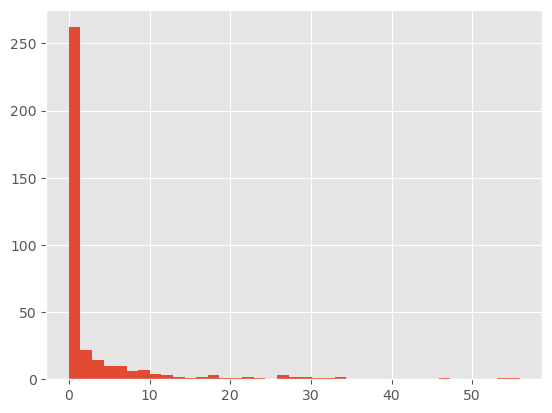

In [48]:
%matplotlib inline
plt.style.use('ggplot')

plt.hist(rainfall_mm, bins='auto')

plt.show()

## **Comparison Operators as Ufuncs**

In [49]:
x = np.arange(1, 6)

x

array([1, 2, 3, 4, 5])

In [51]:
x < 3

array([ True,  True, False, False, False])

In [52]:
x >= 3

array([False, False,  True,  True,  True])

In [53]:
x != 3

array([ True,  True, False,  True,  True])

In [54]:
x == 3

array([False, False,  True, False, False])

In [55]:
(x * 2) == (x ** 2)

array([False,  True, False, False, False])

| Operator | Equivalent ufunc | Operator | Equivalent ufunc |
| :--- | :--- | :--- | :--- |
| `==` | `np.equal` | `!=` | `np.not_equal` |
| `<` | `np.less` | `<=` | `np.less_equal` |
| `>` | `np.greater` | `>=` | `np.greater_equal` |

## **Working with Boolean Arrays**

In [57]:
x = rng.integers(1, 10, size=(3, 4))

x

array([[4, 4, 9, 9],
       [3, 3, 5, 1],
       [1, 4, 1, 1]])

### **Counting Entries**

In [58]:
# count how many values are less than 6
np.count_nonzero(x < 6)

np.int64(10)

In [60]:
# count how many values are less than 6 by rows
np.count_nonzero(x < 6, axis=1)

array([2, 4, 4])

In [59]:
np.sum(x < 6)

np.int64(10)

In [61]:
np.any(x > 8)

np.True_

In [62]:
np.all(x > 0)

np.True_

In [64]:
np.all(x < 8, axis=1)

array([False,  True,  True])

### **Boolean Operators**

In [65]:
np.sum((rainfall_mm > 10) & (rainfall_mm < 20))

np.int64(16)

In [67]:
np.sum(~((rainfall_mm <= 10) | (rainfall_mm >= 20)))

np.int64(16)

| Operator | Equivalent ufunc | Operator | Equivalent ufunc |
| :--- | :--- | :--- | :--- |
| `&` | `np.bitwise_and` | `\|` | `np.bitwise_or` |
| `^` | `np.bitwise_xor` | `~` | `np.bitwise_not` |

In [68]:
print("Number days without rain: ", np.sum(rainfall_mm == 0))
print("Number days with rain: ", np.sum(rainfall_mm != 0))
print("Days with more than 10 mm: ", np.sum(rainfall_mm > 10))
print("Rainy days with < 5 mm: ", np.sum((rainfall_mm > 0) & (rainfall_mm < 5)))

Number days without rain:  221
Number days with rain:  144
Days with more than 10 mm:  34
Rainy days with < 5 mm:  83


## **Boolean Arrays as Masks**

In [69]:
x

array([[4, 4, 9, 9],
       [3, 3, 5, 1],
       [1, 4, 1, 1]])

In [70]:
# masking operation

x[x < 5]

array([4, 4, 3, 3, 1, 1, 4, 1, 1])

In [72]:
rainy = (rainfall_mm > 0)
days = np.arange(365)
summer = (days > 172) & (days < 262)

print("Median precip on rainy days in 2015 (mm): ", np.median(rainfall_mm[rainy]))
print("Median precip on summer days in 2015 (mm): ", np.median(rainfall_mm[summer]))
print("Maximum precip on summer days in 2015 (mm): ", np.max(rainfall_mm[summer]))
print("Median precip on non-summer rainy days (mm):", np.median(rainfall_mm[rainy & ~summer]))

Median precip on rainy days in 2015 (mm):  3.8
Median precip on summer days in 2015 (mm):  0.0
Maximum precip on summer days in 2015 (mm):  32.5
Median precip on non-summer rainy days (mm): 4.1


## **Using the Keywords and/or Versus the Operators &/|**

The distinction between these two sets of operators is one of the most common "gotchas" in Python, especially when moving between standard programming and data-heavy work with NumPy or Pandas.

- **1. Logical Operators (`and`, `or`, `not`)**
    - These are **Boolean** operators. They evaluate the **entire object** as a single truth value (True or False).
        * **Behavior:** They use "Short-circuiting." If the result is clear from the first value (e.g., `False and ...`), Python doesn't even look at the second value.
        * **Use Case:** Control flow (e.g., `if` statements and `while` loops).
        * **Limitation:** They **cannot** be used on NumPy arrays or Pandas Series. If you try, you will get the famous `ValueError: The truth value of an array with more than one element is ambiguous.`

---

- **2. Bitwise Operators (`&`, `|`, `~`)**
    - In the context of NumPy and Pandas, these are **Element-wise** operators. They perform the operation on every single item in the array simultaneously.
        * **Behavior:** They compare individual bits (or boolean values) at every index. There is no short-circuiting; every element is evaluated.
        * **Use Case:** Filtering data, creating masks, and performing bit-level math.
        * **Precedence:** These have higher precedence than comparison operators. This is why you **must** use parentheses when combining filters: `(x > 5) & (x < 10)`.

---

- **Comparison Table**


| Feature | `and`, `or`, `not` | `&`, `"|"`, `~` |
| :--- | :--- | :--- |
| **Level** | Object-level (Scalar) | Element-level (Vectorized) |
| **Result** | A single True/False | An array of True/False |
| **Short-circuit?** | Yes | No |
| **In NumPy/Pandas** | Fails on arrays | Standard for filtering |

---

- **Why this matters for your Data Pipeline**
    - In your **Comptoire-DWH** project, you will almost exclusively use `&`, `|`, and `~`. 

If you are trying to flag specific transactions in your **Silver** layer, you need the bitwise versions to check every row at once. For example, to find all "Completed" sales that were also "High Value":
```python
# This is correct and vectorized (C-speed)
high_value_sales = (status == 'Completed') & (amount > 1000)

# This would CRASH your pipeline
high_value_sales = (status == 'Completed') and (amount > 1000)
```